# 【課題】糖尿病の進行状況を予測（回帰）しよう

## データを読み込む

まずは、最初のセルを実行し、データを読み込んでください。今回はscikit-learnに標準で入っているデータを使います。

In [14]:
# scikit-learnの糖尿病のデータセットを読み込む（変更しないでください）
from sklearn import datasets
diabetes_data = datasets.load_diabetes()

読み込んだデータについて確認します。

In [15]:
# データセットのDESCRを確認する（変更しないでください）
print(diabetes_data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [16]:
# 読み込んだデータが何行何列かをshapeで確認する（変更しないでください）
print(diabetes_data.data.shape)
print(diabetes_data.target.shape)

(442, 10)
(442,)


このデータは、糖尿病患者に関する10種類のデータを持っています。主要なもののみ、以下に概要を記載します。

- `age`：年齢
- `sex`：性別
- `bmi`：身長と体重から計算されたBMI
- `bp`：血圧の平均

目的変数には、各患者の1年後の糖尿病の進行状況を数値化したものが入っています。

今回は `bmi`（BMI）と `bp`（血圧）を説明変数として採用します。スライスを使い、`diabetes_data` の `data` と `target` から、それぞれ `X` と `y` を作成しましょう。なお、今回はscikit-learnが持つデータを読み込んでいるので、データはndarray型です。一度Pandasに変更してからスライスでも良いですが、ここではndarrayのまま `data` からスライスしています。

In [17]:
# スライスして X と y を作成する（変更しないでください）
X = diabetes_data.data[:, 2:4]
y = diabetes_data.target

`X` の最初の10件を表示して、データがどのようになっているかを確認します。

In [18]:
# 特徴量（説明変数）の最初の10件をスライスして表示する
# （以下にコードを書いてください）
print(X[:10])

[[ 0.06169621  0.02187239]
 [-0.05147406 -0.02632753]
 [ 0.04445121 -0.00567042]
 [-0.01159501 -0.03665608]
 [-0.03638469  0.02187239]
 [-0.04069594 -0.01944183]
 [-0.04716281 -0.01599898]
 [-0.00189471  0.06662945]
 [ 0.06169621 -0.04009893]
 [ 0.03906215 -0.03321323]]


このデータは最初から正規化されているため、このような数値となっています。

`y` のデータも表示してみましょう。

In [19]:
# 目的変数の最初の10件をスライスして表示する
# （以下にコードを書いてください）
print(y[:10])

[151.  75. 141. 206. 135.  97. 138.  63. 110. 310.]


`y`（糖尿病の進行状況）の数値がどのように計測、あるいは計算されたものかについての説明は公表されていませんが、数値が大きいほど、糖尿病が進行しているものと認識してください。

## データの前処理について

今回は、とくに何か前処理を行なう必要はありませんので、スキップして進めます。

## データを訓練データとテストデータに分ける

X および y を訓練データとテストデータに分けましょう。その際、訓練データ8割、テストデータ2割としてください。また、並び順がランダムになるよう、分割してください。

In [26]:
# 訓練データ8割、テストデータ2割に分割する
# （以下にコードを書いてください）
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=0
)

## モデルを作成して訓練する

ここでは、レッスン本文でも利用した「線形回帰モデル」（`LinearRegression`）を使います。また、作成したモデルに訓練データを渡して、学習を行ないます。

In [27]:
# LinearRegressionの線形回帰モデルを作成する
# （以下にコードを書いてください）
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()


# 訓練データを使って訓練を行なう
# （以下にコードを書いてください）
regressor.fit(x_train, y_train)


LinearRegression()

## 期待する性能が出たかを評価する

予測を実行しましょう。

In [28]:
# テストデータを使って予測（回帰）を実行する
# （以下にコードを書いてください）
y_pred = regressor.predict(x_test)
print(y_pred)


[266.41519237 223.09850361 176.16283437 117.5476608  225.12439177
 231.03444343 124.98275645 190.44612396 187.28946116 196.90455086
  95.52106377 184.99388769 103.26437122  76.2523579  252.98848981
 134.32365853 115.80046257  99.56833778  85.94900285 215.35519617
 202.86213359 139.57425783 153.70794383 184.25288008 182.89094659
 158.17900905 157.91382603  93.02835563 173.90578738 170.63354515
 191.46131919  96.02641024 141.52309304 127.39390935 141.133326
 178.0686408  134.40071148 167.5629399  156.66296966 193.21694822
  71.1642953  153.43375621 127.00414231 137.19320061 194.06510445
  86.21868817 144.94944116 176.35546674 117.8688057  228.51221341
 144.91091468 107.11901285 202.74655417 132.7260639  222.01075774
 168.34247398 175.53740619 133.65970387 145.99866056 177.52476786
 176.54809911 175.46035324 172.68502668 131.24855098 193.9835492
 169.77695812  72.08950448 173.97833802 180.09002665  60.4915554
 115.7574338  135.60853908  98.94290959 163.70379597 154.9497956
 155.03135085 1

モデルの評価を行なううえで、まずは予測値と正解値の散布図を作ります。

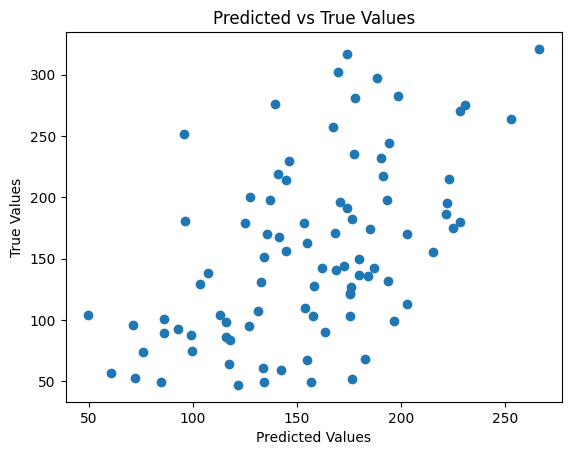

In [23]:
# 横軸が予測値、縦軸は正解値でプロットした散布図を表示する
# （以下にコードを書いてください）
import matplotlib.pyplot as plt
plt.scatter(y_pred, y_test)
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.title('Predicted vs True Values')
plt.show()


正解値と予測値の平均二乗誤差を求めます。

In [29]:
# 正解値と予測値の平均二乗誤差を計算して表示する
# （以下にコードを書いてください）
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 3701.7852915284084


平均二乗誤差の平方根を計算し、正解値と予測値のズレの大きさを求めましょう。

In [30]:
# 平均二乗誤差の平方根を計算して表示する
# （以下にコードを書いてください）
import numpy as np
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)


Root Mean Squared Error: 60.84229853916113
